In [5]:
%pip install pandas scipy seaborn matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%load_ext autoreload
%autoreload 2

In [1]:
# ── Build Master Taxonomy (definitive, safe merge) ───────────────────────────
# Restores clean baseline, deduplicates taxonomy files, merges image + video,
# creates video_label (idxmax) and dominant_funnel_stage (coalesce).
# Guarantees row count stays at 6,244. Saves clean backup first.

import runpy
runpy.run_path("Havas.2/build_master_taxonomy.py")

[INFO] Loading base  →  df_master_backup.csv
       Shape on load : (6244, 40)
[INFO] Dropped stale columns: ['taxonomy_category', 'Awareness_Percentage', 'Consideration_Percentage', 'Conversion_Percentage']
[INFO] Clean baseline: (6244, 36)  (6244 rows)

[INFO] Loading image taxonomy  →  havas_taxonomy_test.csv
       20 unique filenames  |  categories: {'Conversion': 16, 'Consideration': 4}
  ✓ after image merge: 6244 rows  (shape (6244, 39))
       Matched: 20 rows  (0.3%)

[INFO] Loading video taxonomy  →  havas_video_taxonomy_test.csv
  [WARN] 1 duplicate filename(s) in video taxonomy — keeping first
       2071 unique video filenames
  ✓ after video merge: 6244 rows  (shape (6244, 42))
       Matched: 2072 rows  (33.2%)



TypeError: Invalid value '<StringArray>
['Consideration',     'Awareness', 'Consideration',    'Conversion',
     'Awareness', 'Consideration',     'Awareness',     'Awareness',
     'Awareness',     'Awareness',
 ...
    'Conversion',    'Conversion',    'Conversion',     'Awareness',
 'Consideration',     'Awareness', 'Consideration', 'Consideration',
     'Awareness', 'Consideration']
Length: 2072, dtype: str' for dtype 'float64'

In [1]:
import pandas as pd
from pathlib import Path

# Load just the headers of the image taxonomy file
img_test = pd.read_csv(Path("Havas.2/havas_taxonomy_test.csv"), nrows=0)

print("Exact columns in Image Taxonomy CSV:")
print(img_test.columns.tolist())

Exact columns in Image Taxonomy CSV:
['filename', 'category', 'reasoning', 'link']



════════════════════════════════════════════════════
  DOMINANT FUNNEL STAGE — Distribution
════════════════════════════════════════════════════
  Conversion        3994  ( 64.0%)  ███████████████████
  Consideration     1595  ( 25.5%)  ███████
  Awareness          650  ( 10.4%)  ███
  Unknown              5  (  0.1%)  
════════════════════════════════════════════════════



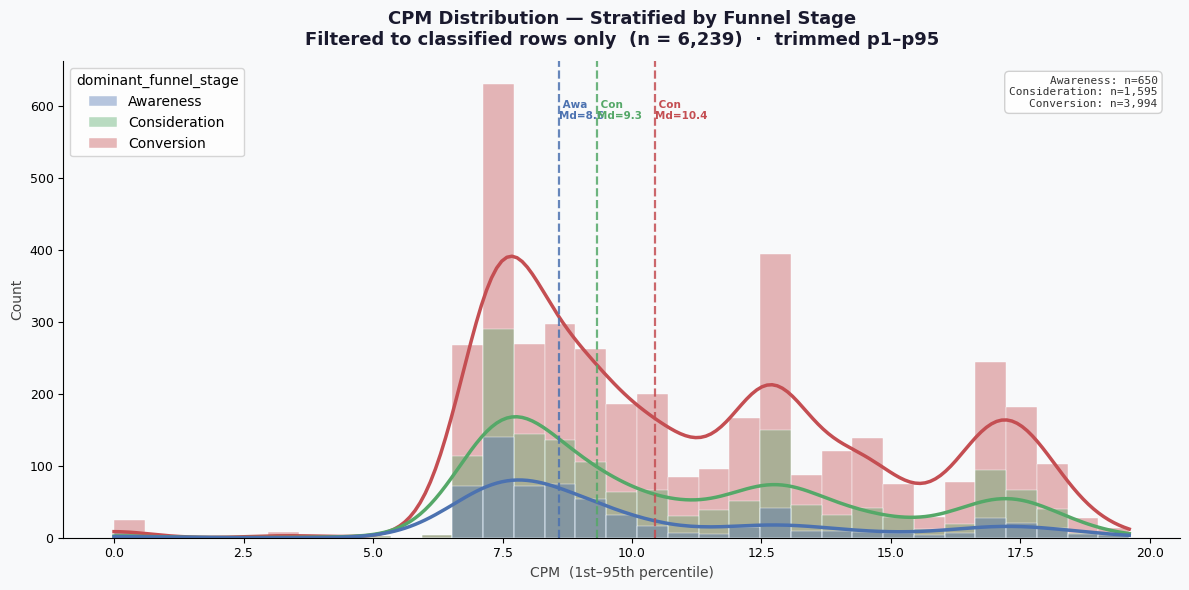

[INFO] Figure saved → eda_step2_stratified_cpm.png


In [1]:
# ── EDA Step 2: Stratified CPM Distribution by Funnel Stage ─────────────────
# Re-plots CPM from EDA Step 1 with hue=dominant_funnel_stage.
# Unknown rows excluded. Log scale applied automatically.

import pandas as pd
from pathlib import Path
from eda_step2_stratified_cpm import run_eda_step2

df_master = pd.read_csv(Path("Havas.2/df_master.csv"))
df_master = run_eda_step2(df_master)



════════════════════════════════════════════════════════════════════════
  STEP A — EFFICIENCY SUMMARY TABLE
════════════════════════════════════════════════════════════════════════
  Stage                 N    CPM Mean   CPM Median    CTR Mean   CTR Median    CPM/CTR
  ────────────────────────────────────────────────────────────────────
  Awareness           650        9.97         8.60     0.00499      0.00129     1996.2
  Consideration      1595       10.79         9.33     0.00888      0.00486     1214.6
  Conversion         3994       11.14        10.44     0.00645      0.00450     1727.2
════════════════════════════════════════════════════════════════════════

  ► Conversion costs +11.7% more CPM than Awareness
  ► Conversion has   +29.1% higher CTR than Awareness
  ► FINDING: CTR gain EXCEEDS CPM premium → cost is justified by click performance.


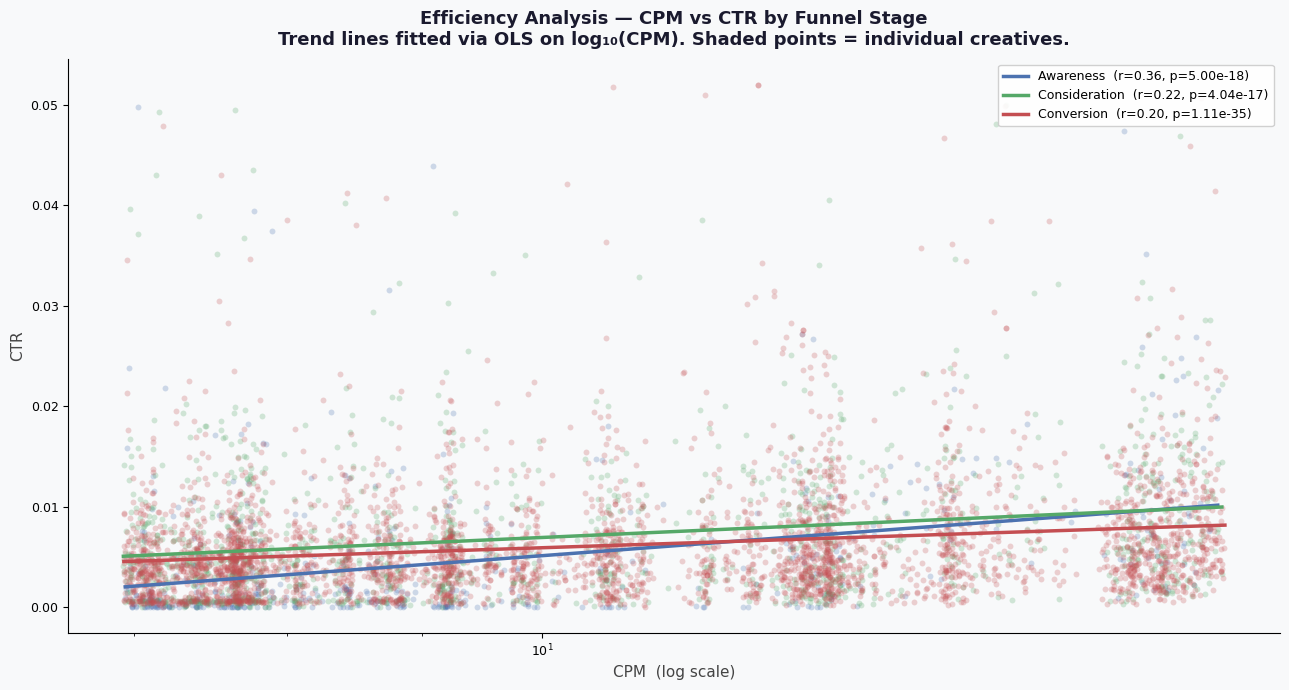

[INFO] Figure saved → eda_step3a_scatter.png

══════════════════════════════════════════════════════════
  STEP B-1 — NORMALITY CHECK (Shapiro-Wilk per group)
══════════════════════════════════════════════════════════
  Stage                   W       p-value     Normal?
  ────────────────────────────────────────────────────
  Awareness          0.7991      1.75e-27        ✗ No
  Consideration      0.8848      8.52e-33        ✗ No
  Conversion         0.9096      1.45e-43        ✗ No
══════════════════════════════════════════════════════════
  → Non-normality detected. Applying log₁₀(CPM) transformation for ANOVA.
    (log-transform stabilises variance and satisfies ANOVA assumptions)

══════════════════════════════════════════════════════════
  STEP B-2 — ONE-WAY ANOVA  (log₁₀(CPM))
══════════════════════════════════════════════════════════
  F-statistic : 34.5597
  p-value     : 1.19e-15
  Significance: ***
──────────────────────────────────────────────────────────
  ✓ REJECT H₀ (p =

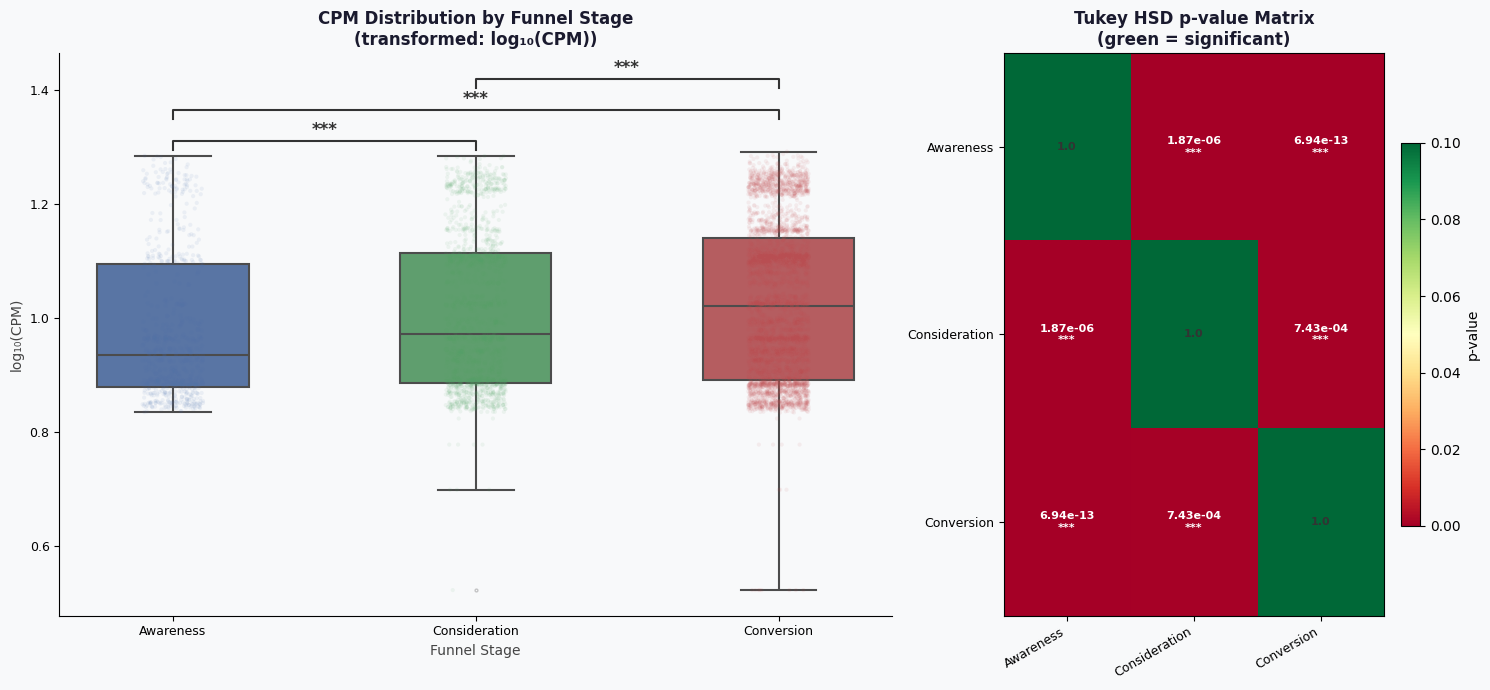

[INFO] Figure saved → eda_step3b_anova.png

╔════════════════════════════════════════════════════════════════╗
║  DISSERTATION VERDICT                                          ║
╠════════════════════════════════════════════════════════════════╣
║  H₀ REJECTED  (F=34.56, p=1.19e-15)                     
║                                                                
║  The null hypothesis — that all funnel stages cost the same —  
║  is OFFICIALLY REJECTED at α=0.05.                            
║                                                                
║  Statistically significant CPM differences confirmed between:  
║    • Awareness vs Consideration                                
║    • Awareness vs Conversion                                   
║    • Consideration vs Conversion                               
║                                                                
║  This supports the use of funnel stage as a cost predictor     
║  and justifies stratified modelling

In [2]:
# ── EDA Step 3: Efficiency Analysis & ANOVA Proof ───────────────────────────
# Step A: CPM vs CTR scatter with OLS trend lines per funnel stage
# Step B: Normality check → One-Way ANOVA → Tukey HSD post-hoc
# Outputs: eda_step3a_scatter.png, eda_step3b_anova.png + console verdict

import pandas as pd
from pathlib import Path
from eda_step3_efficiency_anova import run_eda_step3

df_master = pd.read_csv(Path("Havas.2/df_master.csv"))
run_eda_step3(df_master)


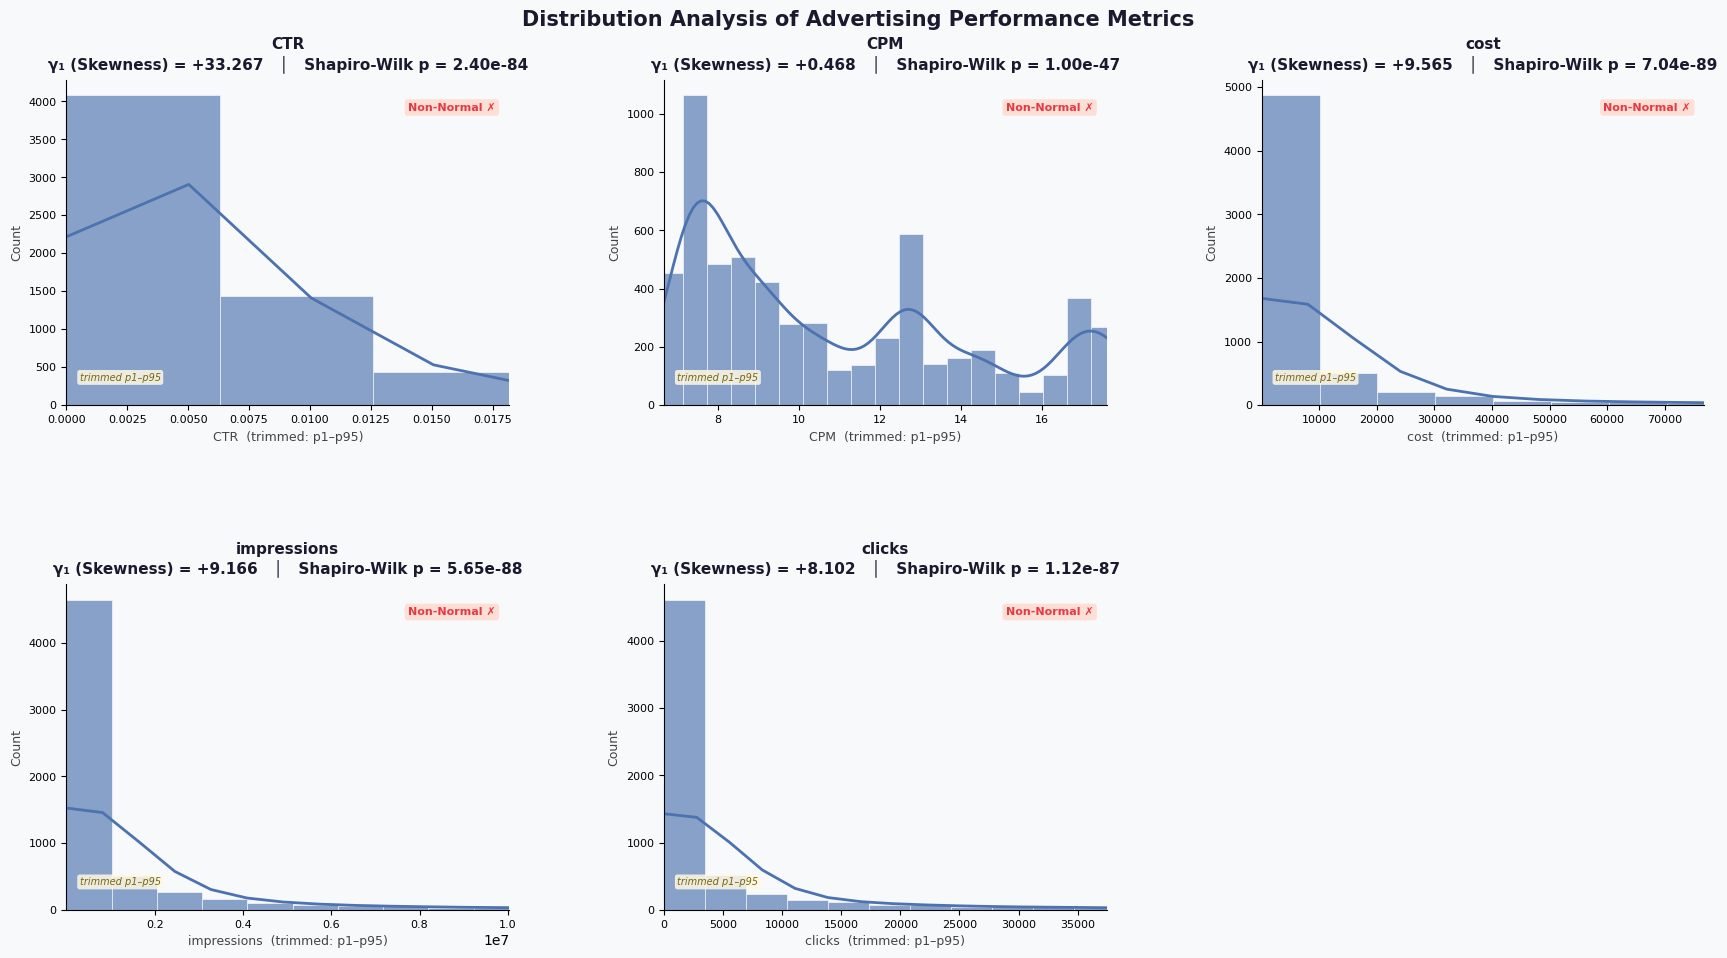


[INFO] Figure saved → eda_step1_distributions.png

══════════════════════════════════════════════════════════════════
  EDA STEP 1 — Normality Test Summary
══════════════════════════════════════════════════════════════════
Variable       N (valid)    Skewness    Shapiro-Wilk p   Normality
──────────────────────────────────────────────────────────────────
CTR                 6244    +33.2673          2.40e-84    REJECTED
CPM                 6244     +0.4684          1.00e-47    REJECTED
cost                6244     +9.5654          7.04e-89    REJECTED
impressions         6244     +9.1658          5.65e-88    REJECTED
clicks              6244     +8.1022          1.12e-87    REJECTED
──────────────────────────────────────────────────────────────────
  H₀: data follows a normal distribution. Rejection at α = 0.05 justifies non-parametric methods.
══════════════════════════════════════════════════════════════════



In [3]:
import pandas as pd
from pathlib import Path
from eda_step1_distributions import run_eda_step1

# 1. Load the raw data from the hard drive
df_master = pd.read_csv(Path("Havas.2/df_master.csv"))

# 2. Clean the Brazilian currency formatting sequentially
df_master['cost_clean'] = df_master['cost'].astype(str)
df_master['cost_clean'] = df_master['cost_clean'].str.replace(r'R\$\s*', '', regex=True)
df_master['cost_clean'] = df_master['cost_clean'].str.replace('.', '', regex=False)
df_master['cost_clean'] = df_master['cost_clean'].str.replace(',', '.', regex=False)

# 3. Overwrite the original cost column with pure mathematical floats
df_master['cost'] = pd.to_numeric(df_master['cost_clean'], errors='coerce')

# 4. NOW execute the statistical plotting pipeline
run_eda_step1(df_master)

In [ ]:
# ── EDA Step 4: Cognitive Embedding Feature Stability Audit ───────────────────
# Selects cognitive_mean_0…9 (temporal means) and cognitive_var_0…9
# (temporal variance; zero-padded for image creatives).
# Source: fix_master_pipeline.py — reconstructed from Embeddings_Videos_Temporal
# Plots 4×5 histogram/KDE grid with dual-layer variance plots (all rows +
# video-only overlay), prints stats table with nonzero_σ, and scaling guide.

import pandas as pd
from pathlib import Path
from eda_step4_vendor_embeddings import run_eda_step4

df_master = pd.read_csv(Path("Havas.2/df_master.csv"))
run_eda_step4(df_master)


In [ ]:
# ── EDA Step 5: Cognitive Feature Audit (Distributions + Collinearity) ────────
# Graph 1: 4×5 histogram/KDE grid for all 20 cognitive columns
#          Blue = cognitive_mean_* | Red = cognitive_var_* (zero-padded for images)
# Graph 2: 20×20 Spearman collinearity heatmap (lower triangle, block-separated)
# Terminal: transposed describe() + WARNING alerts for |ρ| > 0.85 pairs

import pandas as pd
from pathlib import Path
from eda_step5_cognitive_audit import run_eda_step5

df_master = pd.read_csv(Path("Havas.2/df_master.csv"))
run_eda_step5(df_master)


In [ ]:
# ── EDA Step 6: PCA Dimensionality Reduction + Financial Correlation ───────────
# Step 1: Mean block (all rows) → StandardScaler → PCA(90%) → pca_mean_1, pca_mean_2
# Step 2: Var block (video rows only) → StandardScaler → PCA(90%) → pca_var_1, pca_var_2
#         Image rows filled with 0.0 (zero-padding preserved)
# Step 3: Spearman rho heatmap: [pca_mean_*, pca_var_*, is_video] × [CTR, CPM]
# Output: eda_financial_pca_correlation.png + terminal rankings

import pandas as pd
from pathlib import Path
from eda_step6_pca_financial import run_eda_step6

df_master = pd.read_csv(Path("Havas.2/df_master.csv"))
df_enriched = run_eda_step6(df_master)


In [ ]:
# ── EDA Step 7: Bifurcated XGBoost + SHAP Pipeline ────────────────────────────
# Trains 4 separate XGBRegressors: Image-CTR, Image-CPM, Video-CTR, Video-CPM
# Image features : pca_mean_1/2, engajamentoneural, cognitivedemand, focus, funnel OHE
# Video features : + pca_var_1/2 (temporal variance PCA, excluded from image model)
# Step 0: silently regenerates PCA features from cognitive columns
# Step 3: 5-fold CV → R² and MAE per model
# Step 4: SHAP TreeExplainer → 4 summary plots saved as shap_*.png

import pandas as pd
from pathlib import Path
from eda_step7_xgboost_shap import run_eda_step7

df_master = pd.read_csv(Path("Havas.2/df_master.csv"))
run_eda_step7(df_master)


In [ ]:
# ── EDA Step 8: Classification Pivot + K-Means Clustering ──────────────────────
# Part A: XGBClassifier for top-performer detection (CTR >= P75 by group)
#         Grouped threshold = 75th percentile within (is_video × funnel_stage)
#         5-Fold Stratified CV → ROC-AUC + SHAP summary plots
# Part B: K-Means (K=3) on video neural features → archetype cross-tabulation

from eda_step8_classification_clustering import run_eda_step8

run_eda_step8()
